# Sprites y diseño de líneas y flechas de medida

El objetivo de este notebook es diseñar una clase que dibuje (grafique en una figura de matplotlib) líneas de medida, eso es, líneas o flechas para tomar medidas entre dos puntos (o denotar un vector) con una etiqueta. Estas se van a implementar en animaciones

In [1]:
# importamos librerias
import matplotlib.pyplot as plt
import numpy as np

## Trazos iniciales:

Se hace el siguiente trazado para una línea de medida con etiqueta a la izquierda

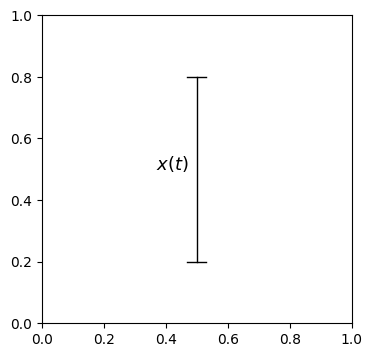

In [2]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(4,4)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

#línea con etiqueta a la derecha
def measure_line(w=1):
    ax.plot([0.5,0.5],[0.2,0.8],color="k", lw=w)
    ax.plot([0.47,0.53],[0.2,0.2],color="k", lw=w)
    ax.plot([0.47,0.53],[0.8,0.8],color="k", lw=w)
    tag = ax.text(0,0,r"$x(t)$", fontsize=13, family = "serif", ha="right")
    tag.set_position( (0.475,0.5) )

measure_line()

Y se tiene el siguiente sketch para una flecha

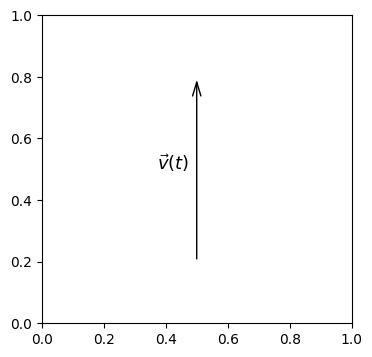

In [3]:
from matplotlib.patches import FancyArrowPatch

#plano
fig, ax = plt.subplots()
fig.set_size_inches(4,4)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

#línea con etiqueta a la derecha
def arrow(w=1):
    ar = FancyArrowPatch((0.5,0.2),(0.5,0.8), arrowstyle='->, head_length={}, head_width={}'.format(10,3), lw=1)
    ax.add_patch(ar)
    tag = ax.text(0,0,r"$\vec{v}(t)$", fontsize=13, family = "serif", ha="right")
    tag.set_position( (0.475,0.5) )

arrow()

## Creación de las clases

Los parametros a considerar para las clases son: \
1.- Eje o subfigura (ax)
2.- Inicio y final del trazo (pos)
3.- Etiqueta o texto (tag)
4.- Posición del texto (tag_pos)
5.- Peso (weight)

De momento el resorte se dibujara vertical en una posición default, con el texto por defalt a la derecha. El como el tag y la línea se orientarán el uno respecto al otro. Ahorita solo trabajemos con el parametro de peso


<bound method Figure.show of <Figure size 600x600 with 1 Axes>>

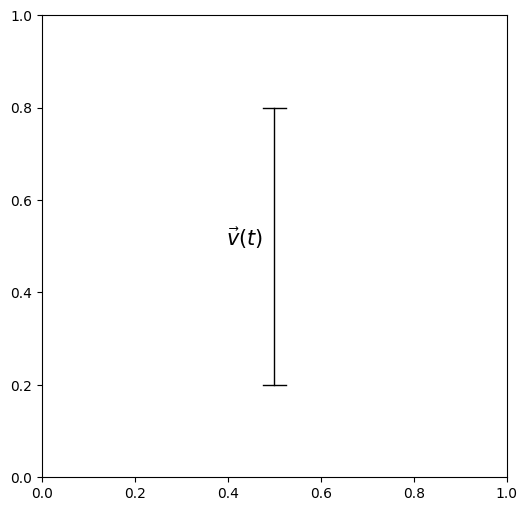

In [4]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(6,6)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

class Measure_line():
    def __init__(self, ax, pos=[(0.5,0.2),(0.5,0.8)], tag="", tag_pos="right", tag_or = 0, weight=1):
        self.ax = ax
        self.pos = pos
        self.tag = tag
        self.tag_pos = tag_pos
        self.tag_or = tag_or
        self.weight = weight

    def draw(self):
        # Creamos las tres lineas de la linea de medida
        self.mline, = ax.plot([0.5,0.5],[0.2,0.8],color="k", lw=self.weight)
        self.h1line, = ax.plot([0.5-0.025*self.weight, 0.5 + 0.025*self.weight],[0.2,0.2],color="k", lw=self.weight)
        self.h1line, = ax.plot([0.5-0.025*self.weight, 0.5 + 0.025*self.weight], [0.8,0.8], color="k", lw=self.weight)
        self.tag = ax.text(0,0, self.tag, fontsize=15*self.weight, family = "serif", ha="right")
        self.tag.set_position( (0.475,0.5) )


ml = Measure_line(ax, weight=1, tag=r"$\vec{v}(t)$")
ml.draw()

fig.show

    
    

Ahora hagamos efectivo el tamagno, definiendo una variable de longitud, y colocando la posicion default en el origen

<bound method Figure.show of <Figure size 600x600 with 1 Axes>>

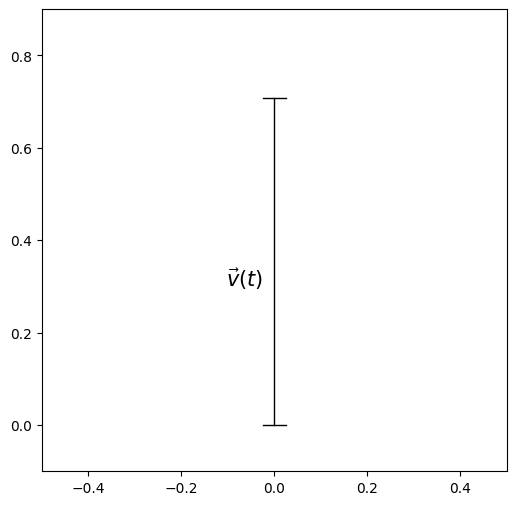

In [5]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(6,6)
ax.set_xlim(-0.5,0.5)
ax.set_ylim(-0.1,.9)

class Measure_line():
    def __init__(self, ax, pos=[(0.0,0.0),(0.0,0.6)], tag="", tag_pos="right", tag_or = 0, weight=1):
        self.ax = ax
        self.pos = pos
        self.tag = tag
        self.tag_pos = tag_pos
        self.tag_or = tag_or
        self.weight = weight

    def draw(self):
        #variable de longitud
        pos = self.pos
        l = np.sqrt( (pos[0][0] - pos[1][0])**2 + (pos[0][1] - pos[1][1])**2 )

        # Creamos las tres lineas de la linea de medida
        self.mline, = ax.plot([0.0,0.0],[0.0,l],color="k", lw=self.weight)
        self.h1line, = ax.plot([-0.025*self.weight, 0.025*self.weight],[0.0,0.0],color="k", lw=self.weight)
        self.h1line, = ax.plot([-0.025*self.weight, 0.025*self.weight], [l,l], color="k", lw=self.weight)
        #creamos el texto
        self.tag = ax.text(0,0, self.tag, fontsize=15*self.weight, family = "serif", ha="right")
        self.tag.set_position( (-.025*self.weight, 0.3) )


ml = Measure_line(ax, pos=[(0,0), (0.5,0.5)] ,weight=1, tag=r"$\vec{v}(t)$")
ml.draw()

fig.show

Ahora definimos una rotacion y traslacion como se hizo con el resorte para ubicar la linea donde queramos

<bound method Figure.show of <Figure size 600x600 with 1 Axes>>

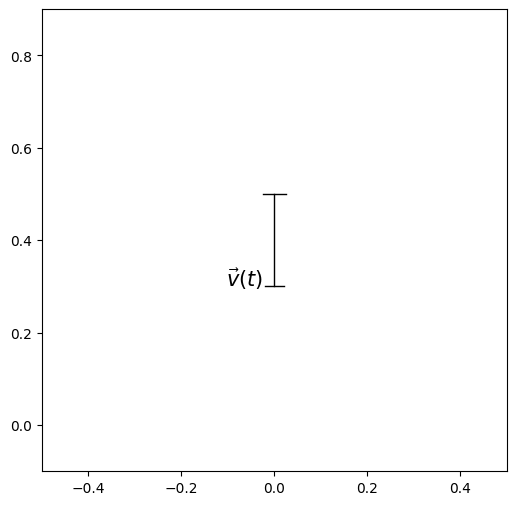

In [12]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(6,6)
ax.set_xlim(-0.5,0.5)
ax.set_ylim(-0.1,.9)

class Measure_line():
    def __init__(self, ax, pos=[(0.0,0.0),(0.0,0.6)], tag="", tag_pos="right", tag_or = 0, weight=1):
        self.ax = ax
        self.pos = pos
        self.tag = tag
        self.tag_pos = tag_pos
        self.tag_or = tag_or
        self.weight = weight

    def draw(self):
        #variable de longitud
        pos = self.pos
        l = np.sqrt( (pos[0][0] - pos[1][0])**2 + (pos[0][1] - pos[1][1])**2 )

        # definimos una función para hacer la rotación de un vecor
        def R(x,y,pos = pos):
            #definimos el angulo de la rotación
            if( (pos[1][0]-pos[0][0])==0 ):
                theta = 0 if (pos[1][1]-pos[0][1])<0 else np.pi
            else:
                theta = np.arctan( (pos[1][1]-pos[0][1])/(pos[1][0]-pos[0][0]) ) - np.pi/2
            theta = theta if (pos[1][0]-pos[0][0])>0 else theta-np.pi
            return np.matmul([x,y],[[np.cos(theta), np.sin(theta)],[-np.sin(theta),np.cos(theta)]])+np.array([pos[0][0], pos[0][1]])

        # Creamos las tres lineas de la linea de medida
        self.mline, = ax.plot([R(0,0)[0] , R(0,l)[0]], [R(0,0)[1] , R(0,l)[1]],color="k", lw=self.weight)
        self.h1line, = ax.plot([R(-0.025*self.weight,0)[0] , R(0.025*self.weight,0)[0]],[R(-0.025*self.weight,0)[1] , R(0.025*self.weight,0)[1]],color="k", lw=self.weight)
        self.h2line, = ax.plot([R(-0.02*self.weight,l)[0] , R(0.02*self.weight,l)[0]],[R(-0.02*self.weight,l)[1] , R(0.02*self.weight,l)[1]], color="k", lw=self.weight)
        #creamos el texto
        self.tag = ax.text(0,0, self.tag, fontsize=15*self.weight, family = "serif", ha="right")
        self.tag.set_position( (-.025*self.weight, 0.3) )


ml = Measure_line(ax, pos=[(0,0.5), (0,0.3)] ,weight=1, tag=r"$\vec{v}(t)$")
ml.draw()

fig.show

Para la flecha ya tenemos un objeto que dibuja la linea justo donde la queremos, asi que la cosa es mas sencilla

<bound method Figure.show of <Figure size 600x600 with 1 Axes>>

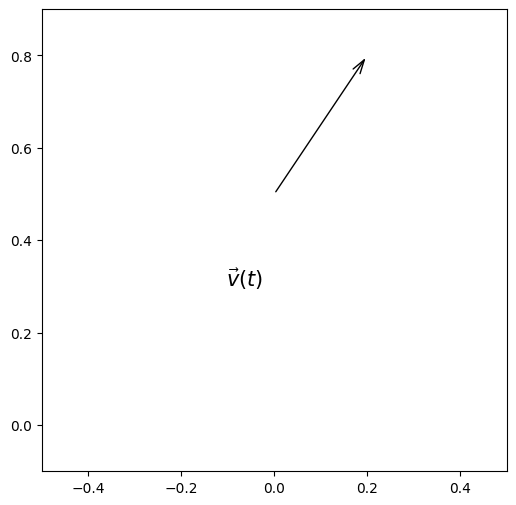

In [9]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(6,6)
ax.set_xlim(-0.5,0.5)
ax.set_ylim(-0.1,.9)

class Measure_arrow():
    def __init__(self, ax, pos=[(0.0,0.0),(0.0,0.6)], tag="", tag_pos="right", tag_or = 0, weight=1):
        self.ax = ax
        self.pos = pos
        self.tag = tag
        self.tag_pos = tag_pos
        self.tag_or = tag_or
        self.weight = weight
    
    def draw(self):
        pos = self.pos
        #creamos y agregamos la flecha
        ar = FancyArrowPatch(pos[0],pos[1], arrowstyle='->, head_length={}, head_width={}'.format(10*self.weight,3*self.weight), lw=1*self.weight)
        ax.add_patch(ar)

        #creamos y agregamos el texto
        self.tag = ax.text(0,0, self.tag, fontsize=15*self.weight, family = "serif", ha="right")
        self.tag.set_position( (-.025*self.weight, 0.3) )
        
ma = Measure_arrow(ax, pos=[(0,0.5), (0.2,0.8)] ,weight=1, tag=r"$\vec{v}(t)$")
ma.draw()

fig.show

## Orientacion de la etiqueta

Para orientar la etiqueta consideremos una elipse de referencia al rededor de la linea o flecha

<bound method Figure.show of <Figure size 400x400 with 1 Axes>>

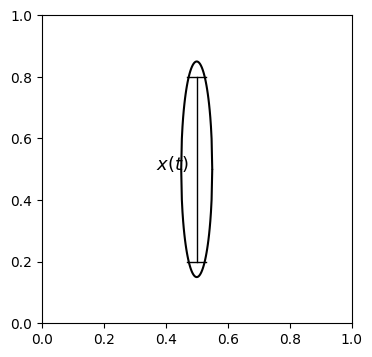

In [28]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(4,4)
ax.set_xlim(0,1)
ax.set_ylim(0,1)

#línea con etiqueta a la derecha
def measure_line(w=1):
    ax.plot([0.5,0.5],[0.2,0.8],color="k", lw=w)
    ax.plot([0.47,0.53],[0.2,0.2],color="k", lw=w)
    ax.plot([0.47,0.53],[0.8,0.8],color="k", lw=w)
    tag = ax.text(0,0,r"$x(t)$", fontsize=13, family = "serif", ha="right")
    tag.set_position( (0.475,0.5) )


X = np.linspace(0.450001,0.549999,50)
Y1 = np.sqrt( 0.35**2 - (0.35**2/0.05**2)*(X-0.5)**2 ) + 0.5
Y2 = -np.sqrt( 0.35**2 - (0.35**2/0.05**2)*(X-0.5)**2 ) + 0.5
ax.plot(X,Y1,color='k')
ax.plot(X,Y2,color='k')
measure_line()
fig.show

El ancho de la elipse es casi un 60% mas grande en su eje menor que el de las lineas de los extremos, y casi 17% mas grande en su eje mayor que el largo de la linea. Para orientar el texto al lado izquierdo, derecho, arriba, o abajo de la linea, podemos usar el angulo de inclinacion de la linea (que nos lo da la funcion R), y con ese usar las eq angulares de la elipse $(r_x \sin(-\theta), r_y \cos(-\theta))$ (Se pone negativo pues si el objeto gira hacia $\theta$, para que la etiqueta siga en el mismo lugar, debe girar -$\theta$). De momento hagamos solo la etiqueta a la derecha.

Consideremos ademas que la ubicacion $(r_x \sin(\theta), r_y \cos(\theta))$ solo tiene sentido en un plano antes de girar el objeto, y que a estos puntos tenemos que aplicarle la tranformacion R

0.0
0.0


<bound method Figure.show of <Figure size 600x600 with 1 Axes>>

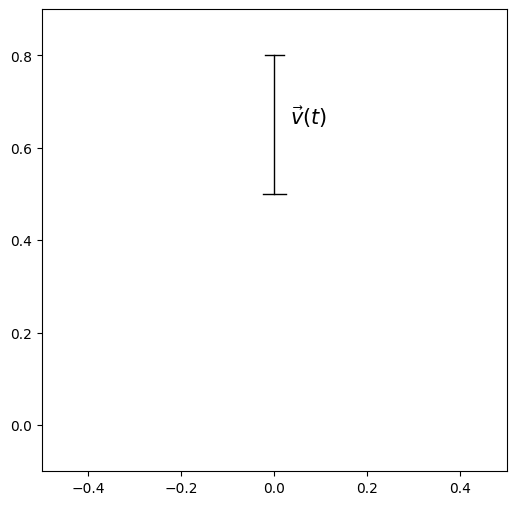

In [98]:
#plano
fig, ax = plt.subplots()
fig.set_size_inches(6,6)
ax.set_xlim(-0.5,0.5)
ax.set_ylim(-0.1,.9)

class Measure_line():
    def __init__(self, ax, pos=[(0.0,0.0),(0.0,0.6)], tag="", tag_pos="left", tag_or = 0, weight=1):
        self.ax = ax
        self.pos = pos
        self.tag = tag
        self.tag_pos = tag_pos
        self.tag_or = tag_or
        self.weight = weight

    def draw(self):
        #variable de longitud
        pos = self.pos
        l = np.sqrt( (pos[0][0] - pos[1][0])**2 + (pos[0][1] - pos[1][1])**2 )

        # definimos una función para hacer la rotación de un vecor
        def R(x,y,pos = pos):
            #definimos el angulo de la rotación
            if( (pos[1][0]-pos[0][0])==0 ):
                theta = 0 if (pos[1][1]-pos[0][1])<0 else np.pi
            else:
                theta = np.arctan( (pos[1][1]-pos[0][1])/(pos[1][0]-pos[0][0]) ) - np.pi/2
            theta = theta if (pos[1][0]-pos[0][0])>0 else theta-np.pi
            return np.append( np.matmul([x,y],[[np.cos(theta), np.sin(theta)],[-np.sin(theta),np.cos(theta)]])+np.array([pos[0][0], pos[0][1]]), theta)

        # Creamos las tres lineas de la linea de medida
        self.mline, = ax.plot([R(0,0)[0] , R(0,l)[0]], [R(0,0)[1] , R(0,l)[1]],color="k", lw=self.weight)
        self.h1line, = ax.plot([R(-0.025*self.weight,0)[0] , R(0.025*self.weight,0)[0]],[R(-0.025*self.weight,0)[1] , R(0.025*self.weight,0)[1]],color="k", lw=self.weight)
        self.h2line, = ax.plot([R(-0.02*self.weight,l)[0] , R(0.02*self.weight,l)[0]],[R(-0.02*self.weight,l)[1] , R(0.02*self.weight,l)[1]], color="k", lw=self.weight)
        
        #creamos el texto
        #extraemos el angulo de rotacion
        theta = R(0,0)[2]
        self.tag = ax.text(0,0, self.tag, fontsize=15*self.weight, family = "serif", ha=self.tag_pos)
        print(R( 0.035*self.weight*np.sin(-theta), l*1.2*self.weight*np.cos(-theta)/2 )[0])
        print(theta)
        self.tag.set_position( ( R(0.035*self.weight*np.cos(-theta), l*1.2*self.weight*np.sin(-theta)/2+l/2 )[0], R(0.035*self.weight*np.cos(-theta), l*1.2*self.weight*np.sin(-theta)/2+l/2))[1] )


ml = Measure_line(ax, pos=[(0,0.5), (-0,0.8)] ,weight=1, tag=r"$\vec{v}(t)$")
ml.draw()

fig.show

In [30]:
np.append( np.array([1,2,3]), 8 )

array([1, 2, 3, 8])